In [1]:
%load_ext autoreload
%autoreload 2

In [90]:
import json
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

os.environ["USE_PYGEOS"] = "0"
import geopandas as gpd

sys.path.append("..")
sys.path.append("../..")
from src.paper_analysis_hydropower import (
    NationalAnalysisHydropower,
    plot_pre_post_bias_correction_validation,
)
from src import data_processing_projections
from src.data_processing_projections import DataProcessingDask

from src.utils_polygons import (
    get_points_in_polygons,
)

from src.utils_streamflow_hydropower import (
    aggregate_polygon_to_plant_flow,
    compute_generation_vectorized,
    compute_hydropower_production_vectorized
)
from src.extract_runoff_prevah import transform_coords_old_to_new_swiss
import dask
from dask.diagnostics import ProgressBar

In [3]:
paths = json.load(open("../paths_projections.json"))

path_data = Path(paths["path_data_ror"])

path_data_hydro = path_data / "hydropower"
path_data_polygons = path_data / "polygons"
path_swiss_maps = path_data / "maps" / "swissboundaries3d_2023-01_2056_5728/"

path_figs = Path(paths["path_figs"])

In [4]:
dask.config.set(num_workers=15, threads_per_worker=16)
dask.config.set(
    {
        "distributed.worker.memory.target": 0.7,  # Spill to disk at 70%
        "distributed.worker.memory.spill": 0.8,  # Start spilling at 80%
        "distributed.worker.memory.pause": 0.9,  # Pause worker at 90%
        "array.chunk-size": "512MiB",
        "logging.distributed": "error",  # Less verbose logs
    }
)

In [5]:
climate_model_chain = None
climate_scenario = None

# climate_model_chain = "CNRM-ALADIN63_CNRM-CERFACS-CNRM-CM5_r1i1p1"
# climate_scenario = "rcp85"

In [6]:
processing = DataProcessingDask(
    "../paths_projections.json", climate_model_chain, climate_scenario
)

Loading data


In [7]:
if climate_model_chain is None and climate_scenario is None:
    df_prevah_pts_in_polygons_filename = "df_prevah_obs_pts_in_polygons.csv"
else:
    df_prevah_pts_in_polygons_filename = "df_prevah_proj_pts_in_polygons.csv"

# Compute hydropower

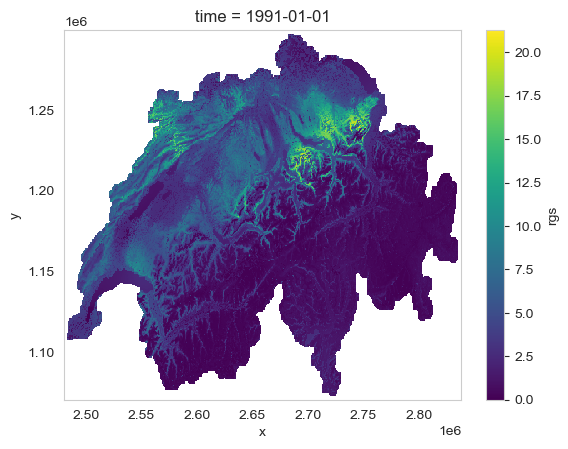

In [8]:
path_rgs = processing.path_data_prevah / "rgs.zarr"
xr.open_zarr(path_rgs, chunks="auto").isel(time=0).rgs.plot()

## Create point in polygon matching

In [17]:
# processing.extract_points_in_polygons()

## PREVAH polygon grid

### Compare with old method

The old method computed the accumulated streamflow per polygon, meaning that we don't go through getting the per grid point matching with a polygon, but rather for each polygon we get the points that match with it. That means that when a polygon does not have an intersecting point, it will take the nearest one to it. This sometimes happens because of the shape of the polygons. It means that a point can contribute to multiple polygons. With the new method, a point can only contribute to one polygon, leaving more than 1000 polygons without a point assigned to it.

An option is to switch to a sparse matrix to have a point contributing to multiple polygons.

In [51]:
df_prevah_pts_in_polygons = pd.read_csv(
    processing.path_data_polygons / df_prevah_pts_in_polygons_filename
)

In [57]:
df_prevah_pts_in_polygons_old = pd.read_csv("/landclim/yhaddad/paper1/data/polygons/df_prevah_500_pts_in_polygons.csv")

In [70]:
df_prevah_pts_in_polygons_proj = pd.read_csv("/landclim/yhaddad/hydropower/hydropower_projections/ror/polygons/df_prevah_proj_pts_in_polygons.csv")

Found 1419 missing EZGNR(s). Example: [163840, 172032, 163844, 172038, 155658, 106507, 155669, 114714, 172071, 172072]


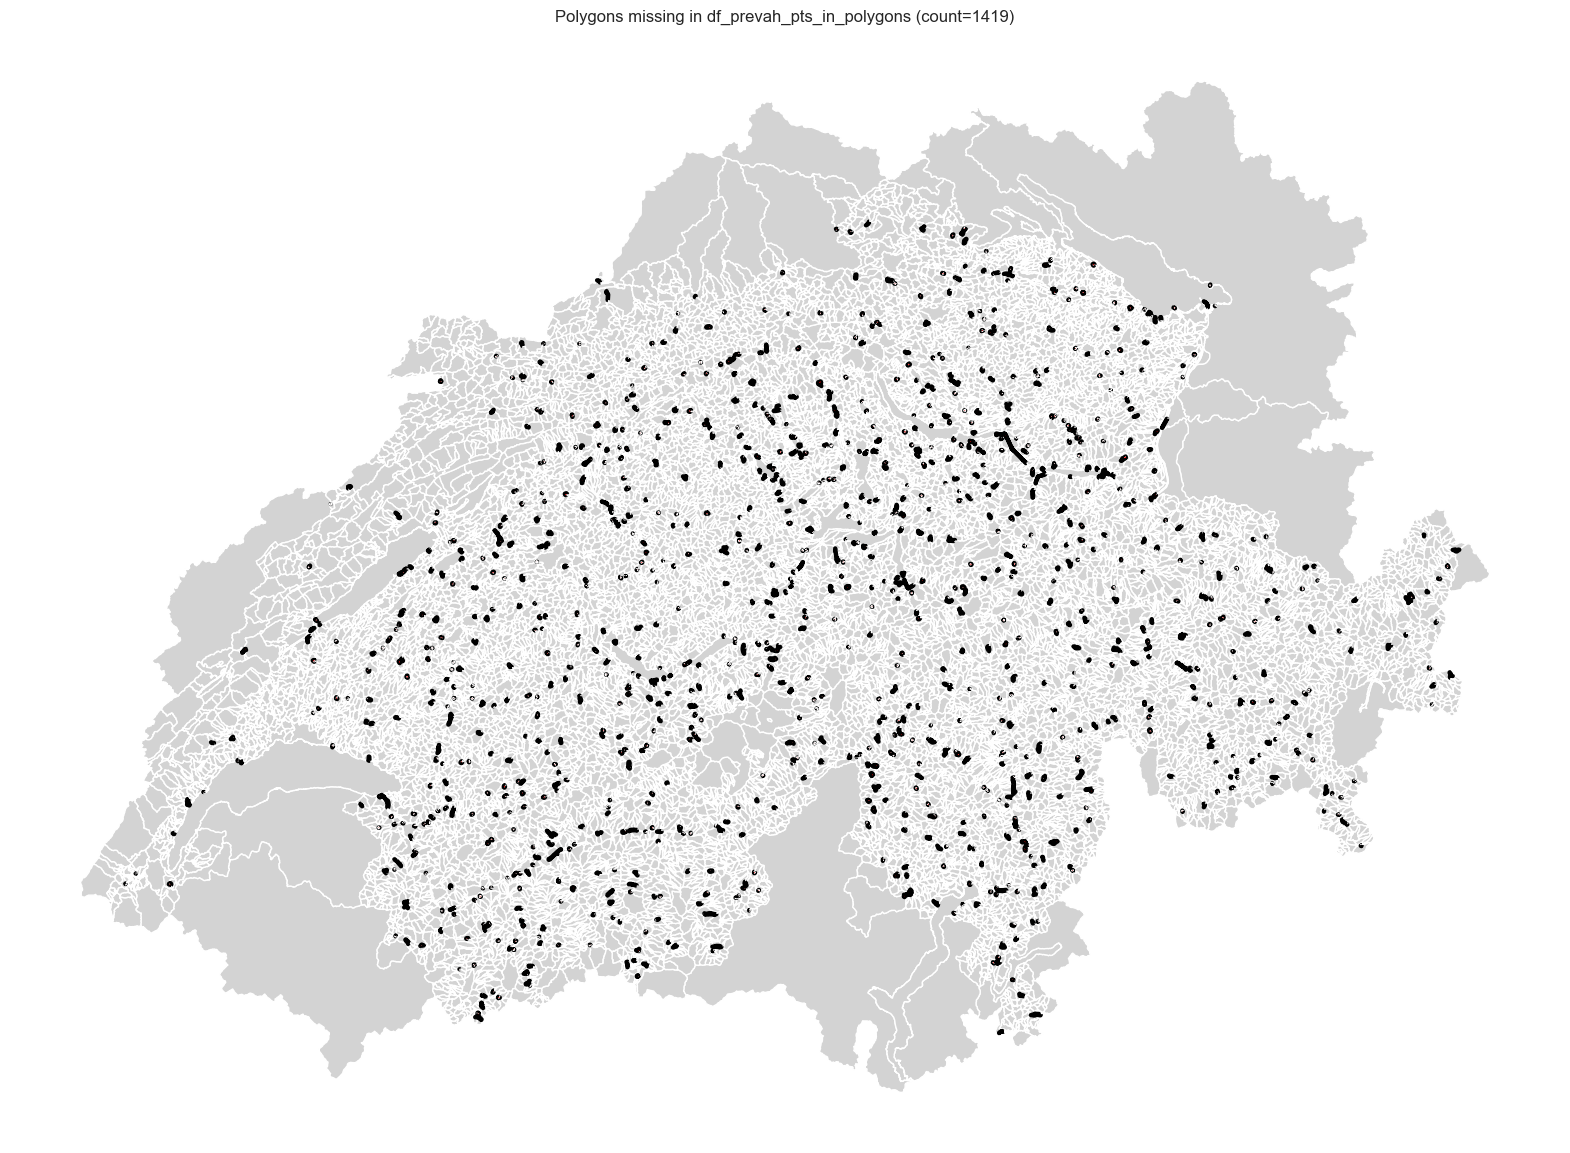

In [89]:
import numpy as np

# find EZGNRs present in the old dataframe but missing in the current one,
# then plot those polygons from the available gdf (processing.gdf_polygons).

import matplotlib.pyplot as plt

# normalize to integers (drop NaNs if any)
missing_ezg = list(set(processing.gdf_polygons["EZGNR"].unique()) - set(df_prevah_pts_in_polygons["EZGNR"].unique()))
print(f"Found {len(missing_ezg)} missing EZGNR(s). Example: {missing_ezg[:10]}")

# subset polygon GeoDataFrame
gdf_polygons = processing.gdf_polygons  # available in the notebook
gdf_missing = gdf_polygons[gdf_polygons["EZGNR"].isin(missing_ezg)]

# plot
fig, ax = plt.subplots(1, 1, figsize=(20, 20))
gdf_polygons.plot(ax=ax, color="lightgrey", edgecolor="white")
if not gdf_missing.empty:
    gdf_missing.plot(ax=ax, color="red", edgecolor="black", linewidth=3)
    ax.set_title(f"Polygons missing in df_prevah_pts_in_polygons (count={len(missing_ezg)})")
else:
    ax.set_title("No missing polygons found")
ax.set_axis_off()
plt.show()

In [113]:
gdf_polygons[gdf_polygons["EZGNR"].isin(missing_ezg)].geometry.area / 1e6

9        0.066958
32       0.020130
40       0.075241
47       0.003545
51       0.022618
           ...   
21802    0.114260
21803    0.051379
21845    0.206759
21847    0.038240
21848    0.097302
Length: 1419, dtype: float64

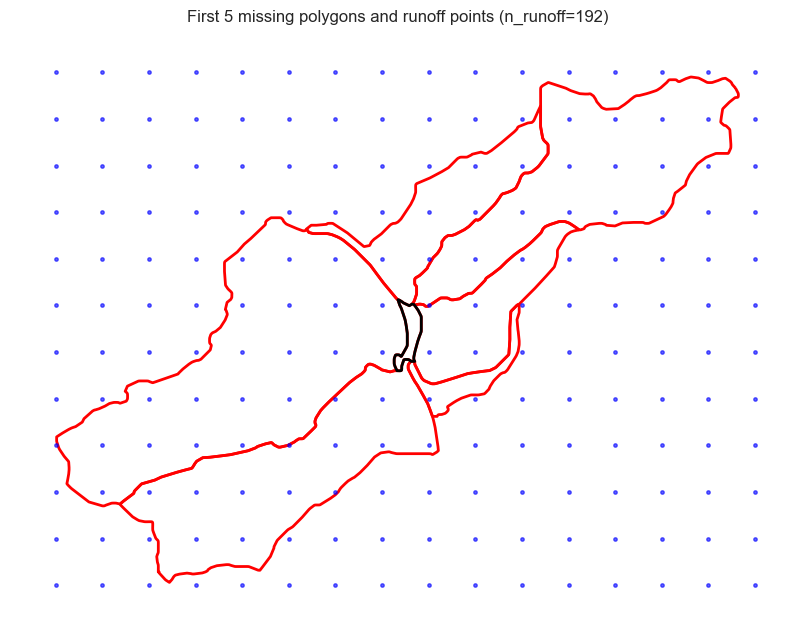

In [117]:
# plot first 5 missing polygons and overlay runoff points within their bounding box
gdf_sel = gdf_polygons[gdf_polygons["EZGNR"] == missing_ezg[120]]

if gdf_sel.empty:
    print("No polygons selected.")
else:
    minx, miny, maxx, maxy = gdf_sel.total_bounds

    # filter runoff points to the polygon bounding box to avoid plotting all ~300k points
    gdf_runoff_sub = gdf_runoff[
        (gdf_runoff["x"] >= minx - 500) & (gdf_runoff["x"] <= maxx + 500) & (gdf_runoff["y"] >= miny - 500) & (gdf_runoff["y"] <= maxy + 500)
    ]
    # find neighboring polygons that touch or are within one grid cell (500 m) of the selected polygon(s)
    sel_union = gdf_sel.geometry.unary_union
    buffer = prevah_grid_resolution  # 500 m

    # use spatial index to limit candidates to those whose bbox intersects an expanded bbox around the selection
    minx_sel, miny_sel, maxx_sel, maxy_sel = gdf_sel.total_bounds
    bounds = (minx_sel - buffer, miny_sel - buffer, maxx_sel + buffer, maxy_sel + buffer)
    candidate_idx = list(gdf_polygons.sindex.intersection(bounds))
    gdf_candidates = gdf_polygons.iloc[candidate_idx]

    # neighbors are those that touch the selection or lie within the buffer distance
    gdf_neighbors = gdf_candidates[
        gdf_candidates.geometry.touches(sel_union) | (gdf_candidates.geometry.distance(sel_union) <= buffer)
    ]

    # exclude already selected polygons and append neighbors to gdf_sel
    gdf_neighbors = gdf_neighbors[~gdf_neighbors.index.isin(gdf_sel.index)]
    gdf_pol_all = pd.concat([gdf_sel, gdf_neighbors], ignore_index=True)

    # recompute bounding box and runoff subset to reflect the expanded selection
    minx, miny, maxx, maxy = gdf_pol_all.total_bounds
    gdf_runoff_sub = gdf_runoff[
        (gdf_runoff["x"] >= minx - 500)
        & (gdf_runoff["x"] <= maxx + 500)
        & (gdf_runoff["y"] >= miny - 500)
        & (gdf_runoff["y"] <= maxy + 500)
    ]
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    gdf_neighbors.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=2)
    gdf_sel.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2, label="Selected polygon")
    if not gdf_runoff_sub.empty:
        gdf_runoff_sub.plot(ax=ax, markersize=6, color="blue", alpha=0.6)
    ax.set_title(f"First 5 missing polygons and runoff points (n_runoff={len(gdf_runoff_sub)})")
    ax.set_xlim(minx - 500, maxx + 500)
    ax.set_ylim(miny - 500, maxy + 500)
    ax.set_axis_off()
    plt.show()

### Create polygon grid

In [58]:
grid_pt_in_polygon = processing.create_prevah_polygon_grid(
    df_prevah_pts_in_polygons_filename=df_prevah_pts_in_polygons_filename,
    fill_value=-1
)

In [59]:
grid_pt_in_polygon

<xarray.DataArray 'EZGNR' (y: 459, x: 715)> Size: 3MB
array([[-1, -1, -1, ..., -1, -1, -1],
       [-1, -1, -1, ..., -1, -1, -1],
       [-1, -1, -1, ..., -1, -1, -1],
       ...,
       [-1, -1, -1, ..., -1, -1, -1],
       [-1, -1, -1, ..., -1, -1, -1],
       [-1, -1, -1, ..., -1, -1, -1]])
Coordinates:
  * x        (x) float64 6kB 2.481e+06 2.482e+06 ... 2.838e+06 2.838e+06
  * y        (y) float64 4kB 1.07e+06 1.071e+06 1.072e+06 ... 1.299e+06 1.3e+06

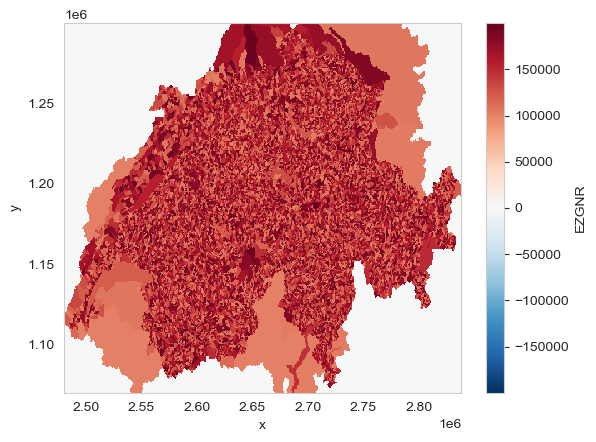

In [60]:
grid_pt_in_polygon.plot()

## Aggregate streamflow at polygon

In [61]:
# Converting streamflow to accumulated streamflow per polygon
streamflow_grid_resolution = 500  # in m
relevant_polygons = processing.gdf_polygons.EZGNR.to_numpy()
print("Computing accumulated streamflow")
path_rgs = processing.path_data_prevah / "rgs.zarr"
ds_rgs = (
    xr.open_zarr(path_rgs, chunks="auto")
    .sel(time="2005")
    .apply(
        lambda v: xr.apply_ufunc(
            data_processing_projections.convert_mm_d_to_cubic_m_s,
            v,
            streamflow_grid_resolution**2,
            vectorize=True,
            dask="parallelized",
            output_dtypes=[v.dtype],
        )
    )
)
# round coordinates to nearest grid resolution to match mask/grid (500 m)
res = streamflow_grid_resolution
new_x = (np.round(ds_rgs.x.values / res) * res).astype(ds_rgs.x.dtype)
new_y = (np.round(ds_rgs.y.values / res) * res).astype(ds_rgs.y.dtype)
ds_rgs = ds_rgs.assign_coords(x=new_x, y=new_y)
print(f"Rounded coordinates to nearest {res} m.")
ds_rgs

Computing accumulated streamflow
Rounded coordinates to nearest 500 m.


<xarray.Dataset> Size: 958MB
Dimensions:  (time: 365, y: 459, x: 715)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2005-01-01 2005-01-02 ... 2005-12-31
  * x        (x) float64 6kB 2.481e+06 2.482e+06 ... 2.838e+06 2.838e+06
  * y        (y) float64 4kB 1.3e+06 1.299e+06 1.298e+06 ... 1.071e+06 1.07e+06
Data variables:
    rgs      (time, y, x) float64 958MB dask.array<chunksize=(361, 256, 256), meta=np.ndarray>

In [62]:
chunks_spatial = {
    "x": data_processing_projections.mode_of(ds_rgs.chunks["x"])[0],
    "y": data_processing_projections.mode_of(ds_rgs.chunks["y"])[0],
}
with ProgressBar(dt=10):
    ds_accum = (
        data_processing_projections.aggregate_streamflow_with_mask(
            ds_rgs,
            processing.grid_pt_in_polygon.chunk(chunks_spatial),
            method="sum",
            fill_value=-1,
            polygons=relevant_polygons,
        )
    ).compute()

[                                        ] | 0% Completed | 289.02 us

KeyboardInterrupt: 

In [ ]:
new_end_time = ds_accum.time[-1] + np.timedelta64(23, "h")
ds_accum_hourly = ds_accum.reindex(
    time=pd.date_range(
        start=ds_accum.time[0].values,
        end=new_end_time.values,
        freq="1H",
        inclusive="both",
    ),
    method="ffill",
)
ds_accum_hourly = ds_accum_hourly.sel(
    time=~(ds_accum_hourly.time.dt.month == 2)
    & ~(ds_accum_hourly.time.dt.day == 29)
)

/tmp/ipykernel_29146/2633881232.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time=pd.date_range(


In [ ]:
ds_accum_hourly_old = xr.open_dataset("/landclim/yhaddad/paper1/data/prevah/ds_prevah_500_streamflow_accum_per_polygon_hourly.nc")

In [67]:
ds_accum_hourly_old

<xarray.Dataset> Size: 49GB
Dimensions:  (time: 280320, polygon: 21858)
Coordinates:
  * time     (time) datetime64[ns] 2MB 1991-01-01 ... 2022-12-31T23:00:00
  * polygon  (polygon) int64 175kB 100001 100002 100003 ... 199987 199991 199993
Data variables:
    rgs      (polygon, time) float64 49GB ...

## Build hydropower parameter table

In [ ]:
df_hydropower_polygons = pd.read_json(
    processing.path_data_hydro
        / "hydropower_polygons"
        / "df_hydropower_polygons.json",
    orient="records",
)

hp_param_df = data_processing_projections.build_hydropower_parameter_table(processing.df_stats_hydropower_ch, df_hydropower_polygons, allowed_types=["L"])

In [ ]:
# concatenate lists from both columns into one 1D numpy array (unique IDs if desired)
s = df_hydropower_polygons["EZGNR"] + df_hydropower_polygons["upstream_EZGNR"]
polygons_array = np.concatenate([np.asarray(v, dtype=int) for v in s.values])
# If you want unique polygon IDs:
polygons_array = np.unique(polygons_array)

polygons_array.shape  # single numpy array of polygon IDs

(21105,)

## Build hydropower polygon matrix

In [ ]:
dtype = "uint8"
polygon_col = "polygons_full"
polygons_all = ds_accum.polygon.values
hp_param_df = data_processing_projections.build_hydropower_parameter_table(processing.df_stats_hydropower_ch, df_hydropower_polygons)
# polygons_all: sorted array of all polygon IDs in ds_accumulated_streamflow_polygon.polygon
poly_index = {pid: i for i, pid in enumerate(polygons_all)}
H = len(hp_param_df)
P = len(polygons_all)
weights = np.zeros((P, H), dtype=dtype)
for j, polys in enumerate(hp_param_df[polygon_col]):
    for pid in polys:
        i = poly_index.get(pid)
        if i is not None:
            weights[i, j] = 1
polygon_plant_weights = xr.DataArray(
    weights,
    dims=("polygon", "hydropower"),
    coords={
        "polygon": polygons_all,
        "hydropower": hp_param_df["WASTANumber"].values,
    },
    name="weights",
)

In [ ]:
polygon_plant_weights

<xarray.DataArray 'weights' (polygon: 20444, hydropower: 703)> Size: 14MB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
Coordinates:
  * polygon     (polygon) float64 164kB 1e+05 1e+05 1e+05 ... 2e+05 2e+05 2e+05
  * hydropower  (hydropower) int64 6kB 100100 100125 100150 ... 900100 900200

## Compute generation

In [ ]:
ds_plant_flow = aggregate_polygon_to_plant_flow(
    ds_accum,
    polygon_plant_weights,
    variable="RGS"
)

In [ ]:
with ProgressBar(dt=10):
    ds_gen = compute_hydropower_production_vectorized(
        ds_accum,
        hp_param_df,
        variable="rgs",
        timestep_hours=24,
        use_simplified_efficiency=False
    ).compute()


In [ ]:
ds_gen.gen.sum("hydropower").sum("time")

<xarray.DataArray 'gen' ()> Size: 8B
array(16.92042911)

In [ ]:
ds_gen_old = xr.open_dataset("/landclim/yhaddad/paper1/data/hydropower/hydropower_generation/ds_prevah_500_hydropower_production_ror_simplified_efficiency.nc")

In [ ]:
ds_gen_old.sel(time="2005").sum()

<xarray.Dataset> Size: 8B
Dimensions:  ()
Data variables:
    gen      float64 8B 17.32